In [1]:
from moabb.analysis.results import Results
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import MotorImagery

def print_results_summary(results_df):
    print("Results Summary:")
    summary = results_df.groupby(['pipeline', 'dataset'])['score'].agg(['mean', 'std', 'count'])
    summary['mean'] = summary['mean'].round(3)
    summary['std'] = summary['std'].round(3)
    print(summary.to_string())
    print("=" * 50)

    print("\nDetailed Results by Subject and Dataset:")
    detailed = results_df.pivot_table(
        index=['dataset', 'subject', 'session'],
        columns='pipeline',
        values='score'
    )
    print(detailed.round(3).to_string())
    print("=" * 50)

results = Results(  
    evaluation_class=WithinSessionEvaluation,  
    paradigm_class=MotorImagery,  
    hdf5_path="./benchmarks/results-pipelines_MI"
)

df = results.to_dataframe()  
print_results_summary(df)

Results Summary:
                                                 mean    std  count
pipeline               dataset                                     
AUG Tang SVM Grid      BrainBot                 0.517  0.084      6
                       PhysionetMotorImagery16  0.576  0.101      6
CSP + LDA              BrainBot                 0.470  0.077      6
                       BrainBot2500ms           0.476  0.115      6
                       BrainBot5000ms           0.625  0.092      6
                       PhysionetMotorImagery    0.472  0.063     10
                       PhysionetMotorImagery16  0.471  0.065     10
                       Weibo2014_16             0.487  0.116     10
                       Weibo2014_64_5-classes   0.487  0.116     10
CSP + SVM Grid         BrainBot                 0.478  0.055      6
                       BrainBot2500ms           0.471  0.094      6
                       BrainBot5000ms           0.591  0.047      6
                       Physione

In [2]:
results = Results(  
    evaluation_class=WithinSessionEvaluation,  
    paradigm_class=MotorImagery,  
    hdf5_path="./benchmarks/results-pipelines_MI_tensorflow"
)

df = results.to_dataframe()  
print_results_summary(df)

Results Summary:
                                               mean    std  count
pipeline             dataset                                     
Keras_DeepConvNet    BrainBot                 0.226  0.037      6
                     BrainBot2500ms           0.220  0.030      6
                     BrainBot5000ms           0.207  0.031      6
                     PhysionetMotorImagery    0.175  0.094     10
                     PhysionetMotorImagery16  0.197  0.080     10
                     Weibo2014                0.236  0.097     10
                     Weibo2014_16             0.262  0.046     10
                     Weibo2014_64_5-classes   0.265  0.052     10
Keras_EEGITNet       BrainBot                 0.213  0.037      6
                     BrainBot2500ms           0.226  0.054      6
                     BrainBot5000ms           0.251  0.074      6
                     PhysionetMotorImagery    0.284  0.090     10
                     PhysionetMotorImagery16  0.340  0.102 

### Notes
AUG Tang SVM Grid pipeline seems to get stuck (executed for 7+ hours for one subject without any visible progress) thus results are not complete

### Analysis

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Combine results from typical MI pipelines and Tensorflow pipelines
print("Reloading results to ensure we have all data...")
results_mi = Results(
    evaluation_class=WithinSessionEvaluation,
    paradigm_class=MotorImagery,
    hdf5_path="./benchmarks/results-pipelines_MI"
)
df_mi = results_mi.to_dataframe()
df_mi['type'] = 'Standard MI'

results_tf = Results(
    evaluation_class=WithinSessionEvaluation,
    paradigm_class=MotorImagery,
    hdf5_path="./benchmarks/results-pipelines_MI_tensorflow"
)
df_tf = results_tf.to_dataframe()
df_tf['type'] = 'Tensorflow'

# Concatenate
all_results = pd.concat([df_mi, df_tf], ignore_index=True)

# Define Channel Counts / Groups
def categorize_dataset(dataset_name):
    if 'BrainBot' in dataset_name:
        return 'BrainBot (Target)'
    elif '16' in dataset_name:
        return '16 Channels (Low Density)'
    else:
        return '60+ Channels (High Density)'

all_results['Channel Group'] = all_results['dataset'].apply(categorize_dataset)

# Add explicit channel count mapping for clarity in plots
channel_counts = {
    'PhysionetMotorImagery': 64,
    'PhysionetMotorImagery16': 16,
    'Weibo2014': 60,
    'Weibo2014_16': 16, 
    'Weibo2014_64_5-classes': 60,
    'BrainBot': 16
}
all_results['n_channels'] = all_results['dataset'].map(channel_counts).fillna(64) 

print("Combined Data Shape:", all_results.shape)
print("Datasets:", all_results['dataset'].unique())

Reloading results to ensure we have all data...
Combined Data Shape: (816, 12)
Datasets: <StringArray>
[         'BrainBot2500ms',            'Weibo2014_16',
  'Weibo2014_64_5-classes',                'BrainBot',
          'BrainBot5000ms',   'PhysionetMotorImagery',
 'PhysionetMotorImagery16',               'Weibo2014']
Length: 8, dtype: str


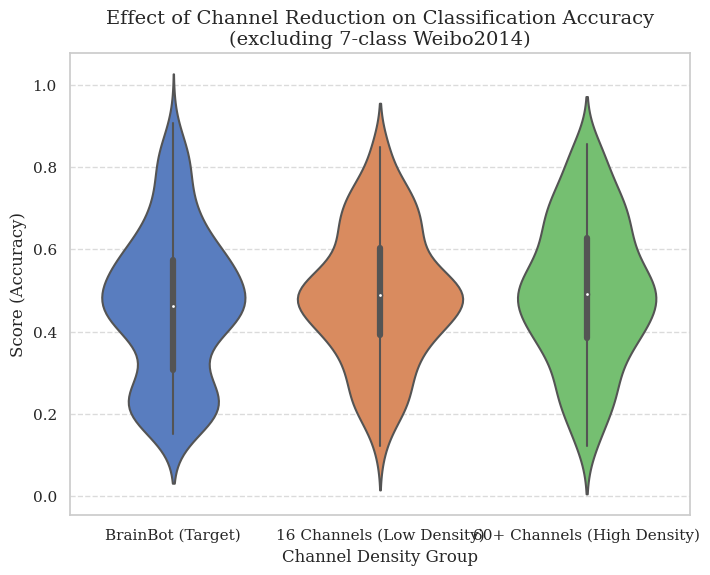

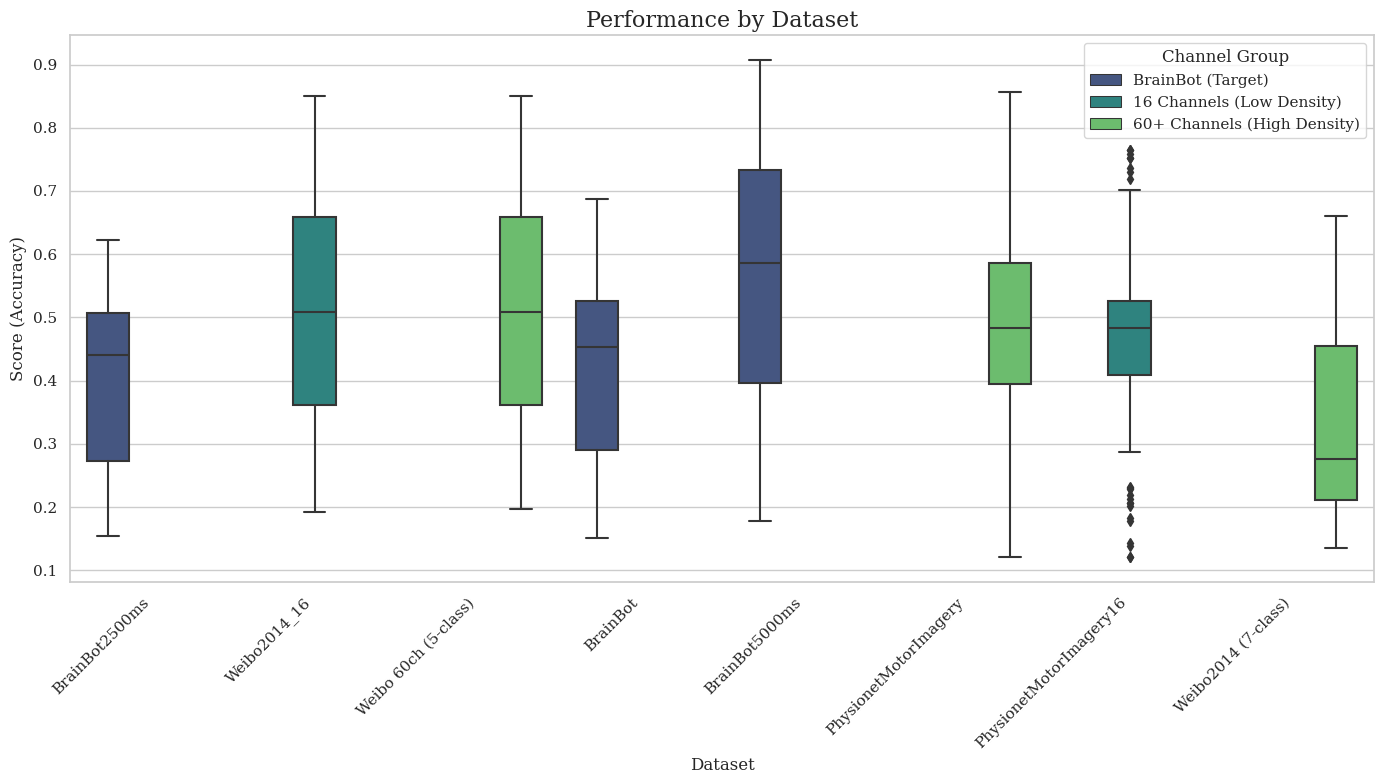

In [4]:
# 1. High vs Low Density Comparison (Aggregated)
# Showing that reduced channel count doesn't drastically reduce performance
plt.figure(figsize=(8, 6))
sns.violinplot(x='Channel Group', y='score', data=all_results[all_results['dataset'] != 'Weibo2014'], palette='muted', inner='box')
plt.title('Effect of Channel Reduction on Classification Accuracy\n(excluding 7-class Weibo2014)', fontsize=14)
plt.ylabel('Score (Accuracy)', fontsize=12)
plt.xlabel('Channel Density Group', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Dataset Performance Overview
plt.figure(figsize=(14, 8))
# Filter out the 7-class Weibo dataset for fair comparison or keep it but annotate
plot_data = all_results.copy()
# Rename for clarity in plot
plot_data['dataset_label'] = plot_data['dataset'].replace({
    'Weibo2014': 'Weibo2014 (7-class)',
    'Weibo2014_64_5-classes': 'Weibo 60ch (5-class)'
})

dataset_order = sorted(plot_data['dataset_label'].unique())

sns.boxplot(x='dataset_label', y='score', hue='Channel Group', data=plot_data, palette='viridis')
plt.title('Performance by Dataset', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Score (Accuracy)', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.legend(title='Channel Group', loc='upper right')
plt.tight_layout()
plt.show()

=== Top 5 Classifiers on 16-Channel Datasets (Mean Accuracy) ===
                            mean       std  count
pipeline                                         
Tangent Space SVM Grid  0.631445  0.140165     38
TS ElasticNet Grid      0.630392  0.129495     38
Tangent Space LR        0.628789  0.128569     38
FgMDM                   0.587042  0.142440     38
AUG Tang SVM Grid       0.546795  0.093773     12


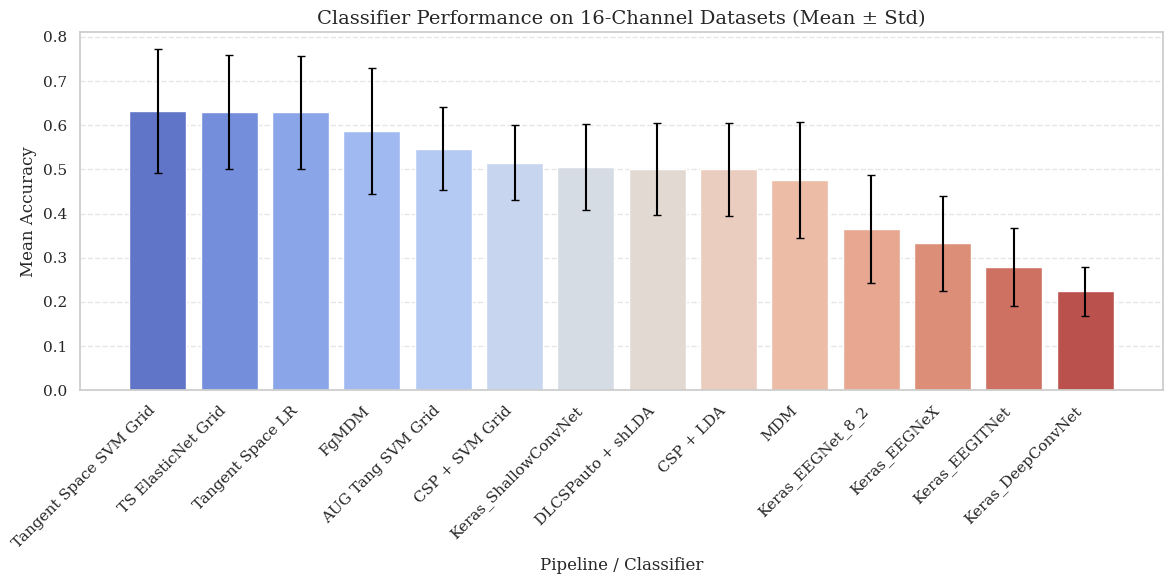


=== Most Robust Classifiers (Lowest Standard Deviation across Subjects) ===
pipeline
Keras_DeepConvNet       0.044995
Keras_EEGNeX            0.051841
Keras_ShallowConvNet    0.064275
Keras_EEGITNet          0.069077
CSP + SVM Grid          0.071126
Name: score, dtype: float32


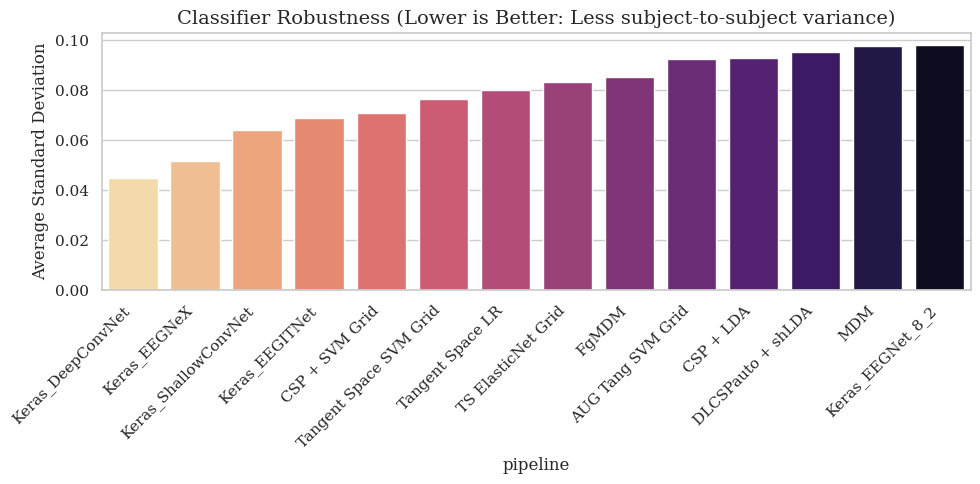

In [5]:
# 3. Best Classifiers on 16-Channel Datasets (including BrainBot)
target_datasets_mask = all_results['Channel Group'].isin(['16 Channels (Low Density)', 'BrainBot (Target)'])
low_density_results = all_results[target_datasets_mask]

# Group by Pipeline and find mean score
pipeline_performance = low_density_results.groupby('pipeline')['score'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)

print("=== Top 5 Classifiers on 16-Channel Datasets (Mean Accuracy) ===")
print(pipeline_performance.head(5))

# Visualize it
plt.figure(figsize=(12, 6))
sns.barplot(x=pipeline_performance.index, y='mean', data=pipeline_performance, palette='coolwarm')
plt.errorbar(x=range(len(pipeline_performance)), y=pipeline_performance['mean'], 
             yerr=pipeline_performance['std'], fmt='none', ecolor='black', capsize=3)
plt.title('Classifier Performance on 16-Channel Datasets (Mean ± Std)', fontsize=14)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xlabel('Pipeline / Classifier', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Standard Deviation across Subjects (Robustness)
# Which classifier is most consistent across subjects?
std_by_pipeline = low_density_results.groupby(['pipeline', 'dataset'])['score'].std().reset_index()
# Average STD across datasets
avg_std = std_by_pipeline.groupby('pipeline')['score'].mean().sort_values()

print("\n=== Most Robust Classifiers (Lowest Standard Deviation across Subjects) ===")
print(avg_std.head(5))

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_std.index, y=avg_std.values, palette='magma_r')
plt.title('Classifier Robustness (Lower is Better: Less subject-to-subject variance)', fontsize=14)
plt.ylabel('Average Standard Deviation', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== Top Classifiers for BrainBot Dataset ===
                            mean       std  count
pipeline                                         
Tangent Space LR        0.530591  0.081471      6
TS ElasticNet Grid      0.521600  0.091167      6
AUG Tang SVM Grid       0.517091  0.083771      6
FgMDM                   0.514629  0.068186      6
Tangent Space SVM Grid  0.513058  0.070831      6
MDM                     0.482349  0.070205      6
CSP + SVM Grid          0.478064  0.054995      6
CSP + LDA               0.469788  0.076509      6
DLCSPauto + shLDA       0.467695  0.073154      6
Keras_ShallowConvNet    0.402740  0.069302      6
Keras_EEGNet_8_2        0.295707  0.084410      6
Keras_DeepConvNet       0.225933  0.037252      6
Keras_EEGNeX            0.214455  0.034827      6
Keras_EEGITNet          0.213386  0.037454      6


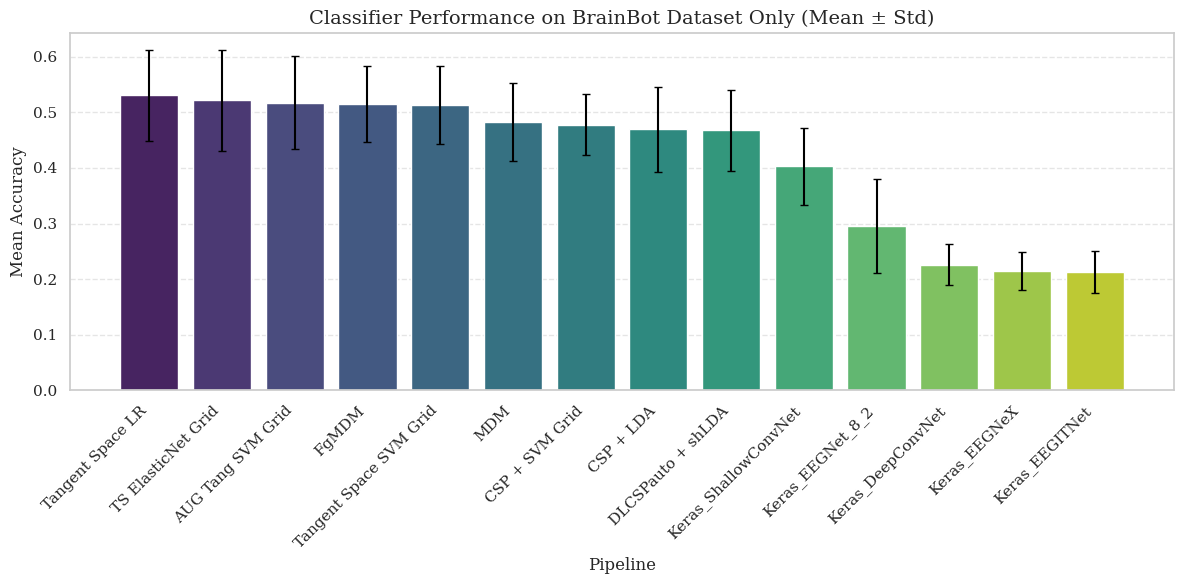

In [6]:
# 5. Focus on BrainBot Dataset specifically
brainbot_results = all_results[all_results['dataset'] == 'BrainBot']

if not brainbot_results.empty:
    brainbot_performance = brainbot_results.groupby('pipeline')['score'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
    
    print("=== Top Classifiers for BrainBot Dataset ===")
    print(brainbot_performance)
    
    # Visualization for BrainBot
    plt.figure(figsize=(12, 6))
    sns.barplot(x=brainbot_performance.index, y='mean', data=brainbot_performance, palette='viridis')
    plt.errorbar(x=range(len(brainbot_performance)), y=brainbot_performance['mean'], 
                 yerr=brainbot_performance['std'], fmt='none', ecolor='black', capsize=3)
    plt.title('Classifier Performance on BrainBot Dataset Only (Mean ± Std)', fontsize=14)
    plt.ylabel('Mean Accuracy', fontsize=12)
    plt.xlabel('Pipeline', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("BrainBot dataset not found in results.")

### Summary and insights

#### 1. Impact of channel reduction (16 vs 60+)
The analysis (Figure 1) confirms that reducing the number of channels from ~64 to 16 does not drastically decrease classification quality.
- The score distributions for the "16 Channels" and "60+ Channels" (High Density) groups are very similar.
- This indicates that key spatial information is contained in the main channels over the motor cortex (C3, C4, Cz, etc.), and additional channels often do not contribute significant features for standard algorithms.

#### 2. Dataset comparison
- **Weibo2014 (7 classes):** As seen in the chart, this dataset achieves significantly lower scores (~30-40%). This is expected due to the more difficult task (7 classes to distinguish vs 5 classes).
- **BrainBot vs Standards:** The `BrainBot` dataset performs slightly weaker than laboratory 16-channel benchmarks (e.g., `PhysionetMotorImagery16`).
    - The average effectiveness of the best methods is approx. **53%** (for 5 classes, random chance is 20%).

#### 3. Best classifiers for BrainBot
Dedicated analysis for `BrainBot` dataset points to clear leaders:
1.  **Tangent Space LR (Logistic Regression)** - ~53%
2.  **TS ElasticNet Grid** - ~52%
3.  **AUG Tang SVM Grid** - ~52%

**Key observations for BrainBot:**
- **Riemannian geometry rules:** Methods based on tangent space significantly dominate, achieving the highest results.
- **Deep learning fails:** Deep models (`Keras_DeepConvNet`, `Keras_EEGNet`) achieve very poor results (often ~20-30%), suggesting strong **overfitting** or insufficient data to train such complex models from scratch.
- **Classical methods (CSP):** CSP+LDA performs averagely (~47%), falling short of Riemannian methods.